OBJETIVO: Análisis de la variación de precios de los materiales más relevantes desde el 2012 al 2023 (Anual y/o mensual)


In [ ]:
#DATASETS ELEGIDO : Precios de materiales de la construcción en Argentina , de www.argentina.gob.ar

IMPORTAMOS LAS LIBRERIAS que utilizaremos

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

COMENZAMOS A REALIZAR EL ANALISIS EDA



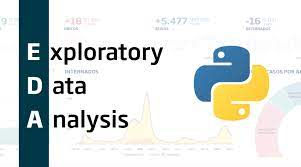

In [34]:
df=pd.read_csv('/content/sample_data/construccion.csv',encoding='ISO-8859-1')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12199 entries, 0 to 12198
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sector_id                  12199 non-null  int64  
 1   sector_nombre              12199 non-null  object 
 2   variable_id                12199 non-null  int64  
 3   actividad_producto_nombre  12199 non-null  object 
 4   indicador                  12199 non-null  object 
 5   unidad_de_medida           12199 non-null  object 
 6   fuente                     12199 non-null  object 
 7   frecuencia_nombre          12199 non-null  object 
 8   cobertura_nombre           12199 non-null  object 
 9   alcance_tipo               12199 non-null  object 
 10  alcance_id                 12199 non-null  int64  
 11  alcance_nombre             12199 non-null  object 
 12  indice_tiempo              12199 non-null  object 
 13  valor                      12199 non-null  flo

In [36]:
df.shape ## El dataset tiene 12199 filas y 14 columnas

(12199, 14)

In [37]:
df.dtypes

sector_id                      int64
sector_nombre                 object
variable_id                    int64
actividad_producto_nombre     object
indicador                     object
unidad_de_medida              object
fuente                        object
frecuencia_nombre             object
cobertura_nombre              object
alcance_tipo                  object
alcance_id                     int64
alcance_nombre                object
indice_tiempo                 object
valor                        float64
dtype: object

In [38]:
df.head(5) ## primeras 5 filas

,sector_id,sector_nombre,variable_id,actividad_producto_nombre,indicador,unidad_de_medida,fuente,frecuencia_nombre,cobertura_nombre,alcance_tipo,alcance_id,alcance_nombre,indice_tiempo,valor
0,24,Construcción,387,Artículos sanitarios de cerámica,ISAC_desestacionalizada,índice base 2004=100,INDEC,Mensual,Nacional,PAIS,200,Argentina,2012-01-01,143.655158
1,24,Construcción,387,Artículos sanitarios de cerámica,ISAC_desestacionalizada,índice base 2004=100,INDEC,Mensual,Nacional,PAIS,200,Argentina,2012-02-01,135.174176
2,24,Construcción,387,Artículos sanitarios de cerámica,ISAC_desestacionalizada,índice base 2004=100,INDEC,Mensual,Nacional,PAIS,200,Argentina,2012-03-01,143.757175
3,24,Construcción,387,Artículos sanitarios de cerámica,ISAC_desestacionalizada,índice base 2004=100,INDEC,Mensual,Nacional,PAIS,200,Argentina,2012-04-01,135.200037
4,24,Construcción,387,Artículos sanitarios de cerámica,ISAC_desestacionalizada,índice base 2004=100,INDEC,Mensual,Nacional,PAIS,200,Argentina,2012-05-01,141.657020


In [39]:
df.columns ## vemos los nombres de las columnas

Index(['sector_id', 'sector_nombre', 'variable_id',
       'actividad_producto_nombre', 'indicador', 'unidad_de_medida', 'fuente',
       'frecuencia_nombre', 'cobertura_nombre', 'alcance_tipo', 'alcance_id',
       'alcance_nombre', 'indice_tiempo', 'valor'],
      dtype='object')

In [40]:
df.dtypes #tipos de datos por columna

sector_id                      int64
sector_nombre                 object
variable_id                    int64
actividad_producto_nombre     object
indicador                     object
unidad_de_medida              object
fuente                        object
frecuencia_nombre             object
cobertura_nombre              object
alcance_tipo                  object
alcance_id                     int64
alcance_nombre                object
indice_tiempo                 object
valor                        float64
dtype: object

In [41]:
from datetime import datetime## importamos libreria para trabajar con fechas

In [42]:
pd.to_datetime(df['indice_tiempo'])

0       2012-01-01
1       2012-02-01
2       2012-03-01
3       2012-04-01
4       2012-05-01
           ...    
12194   2022-01-01
12195   2022-04-01
12196   2022-07-01
12197   2022-10-01
12198   2023-01-01
Name: indice_tiempo, Length: 12199, dtype: datetime64[ns]

Agregamos las columnas de año y mes que se desglosan de la fecha

In [43]:
df['indice_tiempo'] = pd.to_datetime(df['indice_tiempo'])
df['anio'], df['mes'], df['day']= df['indice_tiempo'].dt.year, df['indice_tiempo'].dt.month, df['indice_tiempo'].dt.day

In [44]:
print (df) ## imprimimos el dataframe modificado las columnas de fechas

       sector_id sector_nombre  variable_id         actividad_producto_nombre  \
0             24  Construcción          387  Artículos sanitarios de cerámica   
1             24  Construcción          387  Artículos sanitarios de cerámica   
2             24  Construcción          387  Artículos sanitarios de cerámica   
3             24  Construcción          387  Artículos sanitarios de cerámica   
4             24  Construcción          387  Artículos sanitarios de cerámica   
...          ...           ...          ...                               ...   
12194         24  Construcción          402                      Construcción   
12195         24  Construcción          402                      Construcción   
12196         24  Construcción          402                      Construcción   
12197         24  Construcción          402                      Construcción   
12198         24  Construcción          402                      Construcción   

                           

HASTA ACA hicimos solo el analisis exploratorio y una modificacion sencilla en las columnas de fecha

Ahora comenzamos a analizar las columnas en su detalle

In [45]:
df.loc[:,'actividad_producto_nombre'].unique()

array(['Artículos sanitarios de cerámica', 'Asfalto', 'Cales',
       'Cemento portland', 'Construcción',
       'Hierro redondo y aceros para la construcción',
       'Hormigón elaborado', 'ICC - Nivel general',
       'ISAC - Nivel general', 'ISAC - Resto', 'Ladrillos huecos',
       'Mano de obra', 'Materiales', 'Mosaicos graníticos y calcáreos',
       'Pinturas para construcción', 'Pisos y revestimientos cerámicos',
       'Placas de yeso', 'Yeso'], dtype=object)

 *OBSERVACION DEL ICC:* indice del costo de la construcción-mide las variaciones mensuales que experimenta el costo de la construcción de una vivienda social tipo. El índice está compuesto por tres divisiones llamadas “Capítulos” que involucran los precios de diferentes elementos. Estos son: “Materiales”, comprende los precios de 124 insumos; “Mano de Obra”, 6; y “Varios”, 11.
El conjunto total de los “Capítulos” se clasifica como “Nivel General”, el cual incluye los precios de los 141 elementos
enumerados previamente. Actualmente, la vivienda tipo está compuesta por cocina-comedor, dos dormitorios y baño.
la superficie cubierta es de 50,25 m2, la mampostería es de bloque cerámico con revoque grueso y fino, los pisos son cerámica y el techo de losa

In [46]:
df.loc[:,'alcance_nombre'].unique ## comenzamos por la columna de alcance_nombre a ver que datos tiene

<bound method Series.unique of 0        Argentina
1        Argentina
2        Argentina
3        Argentina
4        Argentina
           ...    
12194    Argentina
12195    Argentina
12196    Argentina
12197    Argentina
12198    Argentina
Name: alcance_nombre, Length: 12199, dtype: object>

In [47]:
df.loc [:,'alcance_nombre'].unique()## en mas detalle porque solo traia el nombre Argentina y tenia tambien otras provincias

array(['Argentina', 'CAPITAL FEDERAL', 'BUENOS AIRES', 'CATAMARCA',
       'CORDOBA', 'CORRIENTES', 'CHACO', 'CHUBUT', 'ENTRE RIOS',
       'FORMOSA', 'JUJUY', 'LA PAMPA', 'LA RIOJA', 'MENDOZA', 'MISIONES',
       'NEUQUEN', 'RIO NEGRO', 'SALTA', 'SAN JUAN', 'SAN LUIS',
       'SANTA CRUZ', 'SANTA FE', 'SANTIAGO DEL ESTERO', 'TUCUMAN',
       'TIERRA DEL FUEGO'], dtype=object)

In [48]:
df.loc[:, 'alcance_tipo'].unique()## luego nos fijamos en la columna alcance_tipo

array(['PAIS', 'PROVINCIA'], dtype=object)

In [49]:
df.loc[:,'unidad_de_medida'].unique() #las unidades de medida están relacionadas al producto

array(['índice base 2004=100', 'tn', 'puestos',
       'índice base dic 2004=100', 'millones de pesos a precios de 2004',
       'millones de pesos a precios corrientes'], dtype=object)

In [50]:
df.loc[:,'indicador'].unique() #El Indicador Sintético de la Actividad de la Construcción (ISAC) refleja la
                                        #evolución del sector de la construcción a partir del comportamiento de un conjunto
                                        #de insumos representativos(Asfalto, cales, cemento, griferias,etc)

array(['ISAC_desestacionalizada', 'ISAC_original', 'ISAC_tendencia-ciclo',
       'Consumo', 'Puestos de trabajo registrados sector privado',
       'Indice del Costo de la Construcción',
       'Valor Agregado Bruto a Precios Básicos'], dtype=object)

In [51]:
df.rename(columns={'actividad_producto_nombre':'producto','alcance_nombre':'alcance','sector_nombre':'sector','frecuencia_nombre':'frecuencia','cobertura_nombre':'cobertura','sector_id':'ID','variable_id':'variable','indice_tiempo':'fecha'},inplace=True)
#Cambiamos los nombres de las columnas

In [52]:
df.columns

Index(['ID', 'sector', 'variable', 'producto', 'indicador', 'unidad_de_medida',
       'fuente', 'frecuencia', 'cobertura', 'alcance_tipo', 'alcance_id',
       'alcance', 'fecha', 'valor', 'anio', 'mes', 'day'],
      dtype='object')

In [61]:
df.loc [:, 'producto'].unique() ## analizamos que tiene la columan de productos



array(['Artículos sanitarios de cerámica', 'Asfalto', 'Cales',
       'Cemento portland', 'Construcción',
       'Hierro redondo y aceros para la construcción',
       'Hormigón elaborado', 'ICC - Nivel general',
       'ISAC - Nivel general', 'ISAC - Resto', 'Ladrillos huecos',
       'Mano de obra', 'Materiales', 'Mosaicos graníticos y calcáreos',
       'Pinturas para construcción', 'Pisos y revestimientos cerámicos',
       'Placas de yeso', 'Yeso'], dtype=object)

In [53]:
tn_cemento=df.loc[(df['unidad_de_medida']=='tn')] #FILTRO COLUMNA "UNIDAD DE MEDIDA" POR TN. Interpretación: el cemento se mide por tonelada
tn_cemento

,ID,sector,variable,producto,indicador,unidad_de_medida,fuente,frecuencia,cobertura,alcance_tipo,alcance_id,alcance,fecha,valor,anio,mes,day
1224,24,Construcción,396,Cemento portland,Consumo,tn,AFCP,Anual,Nacional,PROVINCIA,2,CAPITAL FEDERAL,1996-01-01,590668.0,1996,1,1
1225,24,Construcción,396,Cemento portland,Consumo,tn,AFCP,Anual,Nacional,PROVINCIA,2,CAPITAL FEDERAL,1997-01-01,765723.0,1997,1,1
1226,24,Construcción,396,Cemento portland,Consumo,tn,AFCP,Anual,Nacional,PROVINCIA,2,CAPITAL FEDERAL,1998-01-01,878001.0,1998,1,1
1227,24,Construcción,396,Cemento portland,Consumo,tn,AFCP,Anual,Nacional,PROVINCIA,2,CAPITAL FEDERAL,1999-01-01,779753.0,1999,1,1
1228,24,Construcción,396,Cemento portland,Consumo,tn,AFCP,Anual,Nacional,PROVINCIA,2,CAPITAL FEDERAL,2000-01-01,468504.0,2000,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6691,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,94,TIERRA DEL FUEGO,2021-12-01,3951.0,2021,12,1
6692,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,94,TIERRA DEL FUEGO,2022-01-01,5104.0,2022,1,1
6693,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,94,TIERRA DEL FUEGO,2022-02-01,3834.0,2022,2,1
6694,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,94,TIERRA DEL FUEGO,2022-03-01,5330.0,2022,3,1


In [55]:
tn_cemento_mensual_mendoza=tn_cemento.loc[(tn_cemento['frecuencia']=='Mensual')&(tn_cemento['alcance']=='MENDOZA')&(tn_cemento['anio']==2021)] #Filtro por frecuencia Mensual,en Mendoza, año 2021
tn_cemento_mensual_mendoza  #AFCP= Asociacion de Fabricantes de Cemento Portland HICIMOS UN FILTRO PARA LA PROVINCIA DE MENDOZA POR AÑO

,ID,sector,variable,producto,indicador,unidad_de_medida,fuente,frecuencia,cobertura,alcance_tipo,alcance_id,alcance,fecha,valor,anio,mes,day
4260,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-01-01,45302.0,2021,1,1
4261,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-02-01,39132.0,2021,2,1
4262,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-03-01,51026.0,2021,3,1
4263,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-04-01,47647.0,2021,4,1
4264,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-05-01,44811.0,2021,5,1
4265,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-06-01,47649.0,2021,6,1
4266,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-07-01,57056.0,2021,7,1
4267,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-08-01,56596.0,2021,8,1
4268,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-09-01,62451.0,2021,9,1
4269,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-10-01,61378.0,2021,10,1


In [56]:
tn_cemento_mensual_mendoza.describe() #Descripcion de la distribucion de los datos (media, desviacion estandar, cuartiles)

,ID,variable,alcance_id,valor,anio,mes,day
count,12.0,12.0,12.0,12.000000,12.0,12.000000,12.0
mean,24.0,397.0,50.0,51777.250000,2021.0,6.500000,1.0
std,0.0,0.0,0.0,7406.170537,0.0,3.605551,0.0
min,24.0,397.0,50.0,39132.000000,2021.0,1.000000,1.0
25%,24.0,397.0,50.0,47060.750000,2021.0,3.750000,1.0
50%,24.0,397.0,50.0,50083.000000,2021.0,6.500000,1.0
75%,24.0,397.0,50.0,57576.750000,2021.0,9.250000,1.0
max,24.0,397.0,50.0,62451.000000,2021.0,12.000000,1.0


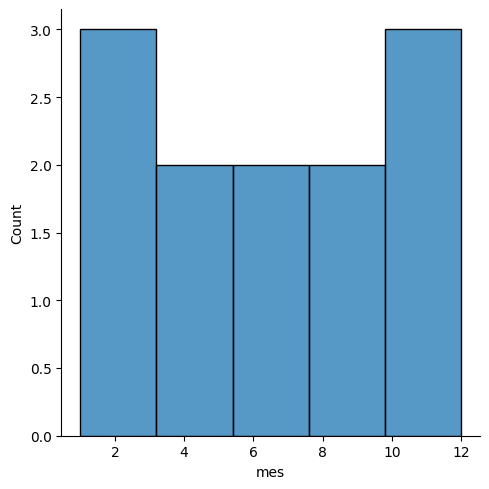

In [57]:
grafico1=sns.displot(tn_cemento_mensual_mendoza['mes']) # REALIZAMOS UN Gráfico CON del valor de la tonelada de cemento.
grafico1                                                #Podemos ver el mín (20mil) y el max (63mil aprox)

In [63]:
df.loc [:, 'frecuencia'].unique()

array(['Mensual', 'Anual', 'Trimestral'], dtype=object)

In [64]:
df.loc [:, 'unidad_de_medida'].unique()

array(['índice base 2004=100', 'tn', 'puestos',
       'índice base dic 2004=100', 'millones de pesos a precios de 2004',
       'millones de pesos a precios corrientes'], dtype=object)

In [70]:
df.columns

Index(['ID', 'sector', 'variable', 'producto', 'indicador', 'unidad_de_medida',
       'fuente', 'frecuencia', 'cobertura', 'alcance_tipo', 'alcance_id',
       'alcance', 'fecha', 'valor', 'anio', 'mes', 'day'],
      dtype='object')

realizamos unos filtros para el filtrocemento en Mendoz

In [71]:
filtrocemento=df.loc [(df['frecuencia']=='Mensual')&  (df['producto']=='Cemento portland') & (df['unidad_de_medida']=='tn') & (df['alcance']=='MENDOZA')]

In [72]:
filtrocemento

,ID,sector,variable,producto,indicador,unidad_de_medida,fuente,frecuencia,cobertura,alcance_tipo,alcance_id,alcance,fecha,valor,anio,mes,day
4056,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2004-01-01,23919.0,2004,1,1
4057,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2004-02-01,23241.0,2004,2,1
4058,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2004-03-01,25200.0,2004,3,1
4059,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2004-04-01,21059.0,2004,4,1
4060,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2004-05-01,20583.0,2004,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4271,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-12-01,49140.0,2021,12,1
4272,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2022-01-01,49031.0,2022,1,1
4273,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2022-02-01,44085.0,2022,2,1
4274,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2022-03-01,53516.0,2022,3,1


Intentamos otro grafico para las columnas del dataframe

In [75]:

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

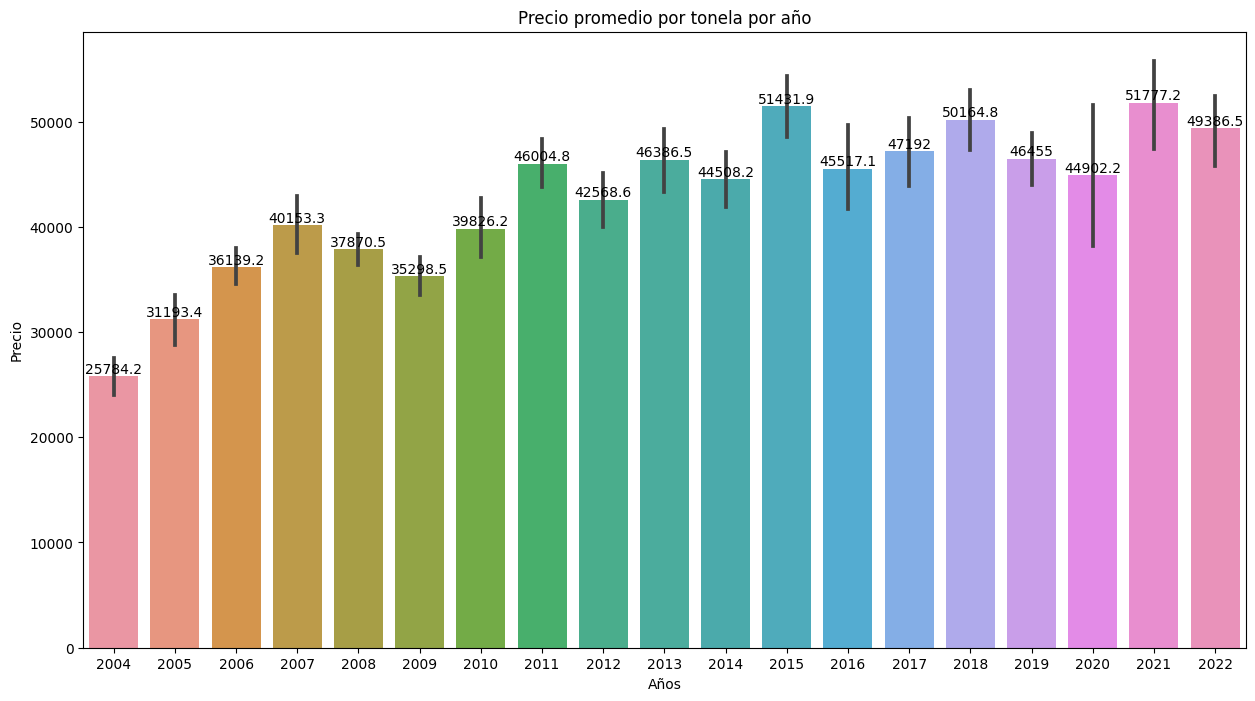

In [76]:
%matplotlib inline
plt.figure(figsize=(15,8))

ax = sns.barplot (filtrocemento,
                 x='anio',
                 y = 'valor')

ax.set(xlabel='Años', ylabel='Precio', title = 'Precio promedio por tonela por año')
plt.bar_label(ax.containers[0], size=10)
plt.tight_layout
plt.show()

EL GRAFICO ANTERIOR no nos da informacion confiable porque..(suponemos que) estamos sumando indices de la construccion por lo que no son montos de precios o consumos y no es una unidad de medida (analizar si son precios... )

In [ ]:
### seguimos intentando con distintos graficos

In [94]:
df.isna().sum() ## nos preguntamos si habia valores nulos

ID                  0
sector              0
variable            0
producto            0
indicador           0
unidad_de_medida    0
fuente              0
frecuencia          0
cobertura           0
alcance_tipo        0
alcance_id          0
alcance             0
fecha               0
valor               0
anio                0
mes                 0
day                 0
dtype: int64

In [95]:
df ['producto'].value_counts()

Cemento portland                                5880
Artículos sanitarios de cerámica                 408
Asfalto                                          408
Placas de yeso                                   408
Pisos y revestimientos cerámicos                 408
Pinturas para construcción                       408
Mosaicos graníticos y calcáreos                  408
Ladrillos huecos                                 408
ISAC - Resto                                     408
ISAC - Nivel general                             408
Hormigón elaborado                               408
Hierro redondo y aceros para la construcción     408
Cales                                            408
Yeso                                             408
ICC - Nivel general                              254
Mano de obra                                     254
Materiales                                       254
Construcción                                     253
Name: producto, dtype: int64

In [96]:
print(df.anio.min())## nos fijamos cual era el año minimo de la columna año

1996


In [97]:
print(df.anio.max())##nos fijamos cual es el año maximo de analisis

2023


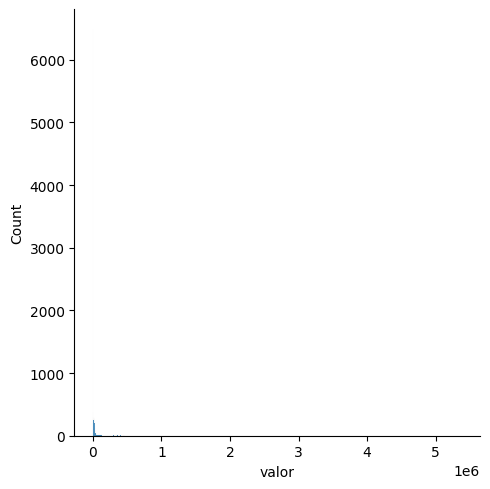

In [83]:
sns.displot(df['valor'])## realizamos un grafico de valores que no nos dio mucha informacion
sns.despine()

In [84]:
z = stats.zscore(np.array(df['valor']))

In [85]:
threshold = 2.5

In [86]:
z_index = df['valor'][np.abs(z) < threshold].index

df_withzscore = df.loc[z_index]

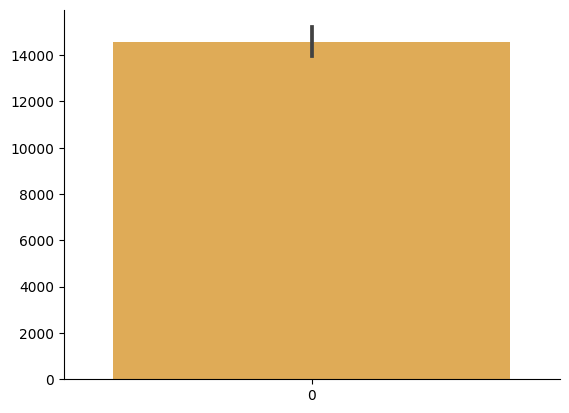

In [89]:
sns.barplot(df_withzscore['valor'], color='#F5B041')
sns.despine()

In [88]:
q1 = df['valor'].quantile(0.25)
q3 = df['valor'].quantile(0.75)

In [ ]:
iqr = q3 - q1
lb = q1 - (iqr * 1.5)
ub = q3 + (iqr * 1.5)

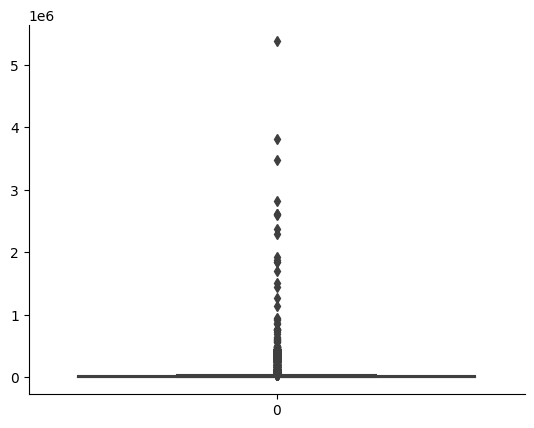

In [93]:
sns.boxplot(df['valor'])
sns.despine()

In [98]:
df.reset_index(drop=True, inplace=True)

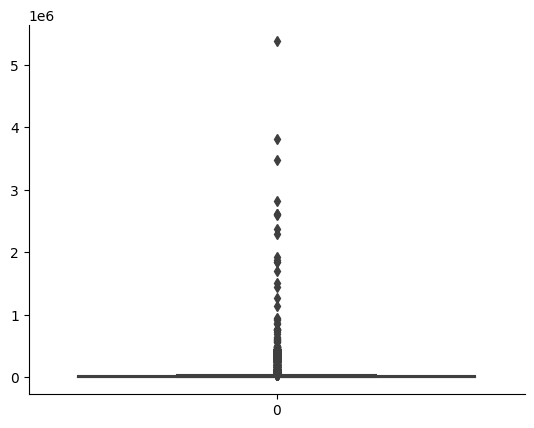

In [99]:
sns.boxplot(df['valor'])## intentamos con un grafico despine
sns.despine()

In [100]:
print(df.valor.min())## nos fijamos cual era el valor maximo y minimo
print(df.valor.max())

4.348960598417
5376046.5398012


Con el analisis anterior nos dimos cuenta que podiamos hacer un grafico por provincias y por valores. Nos dimos cuenta que el valor que trae el mismo es el valor promedio

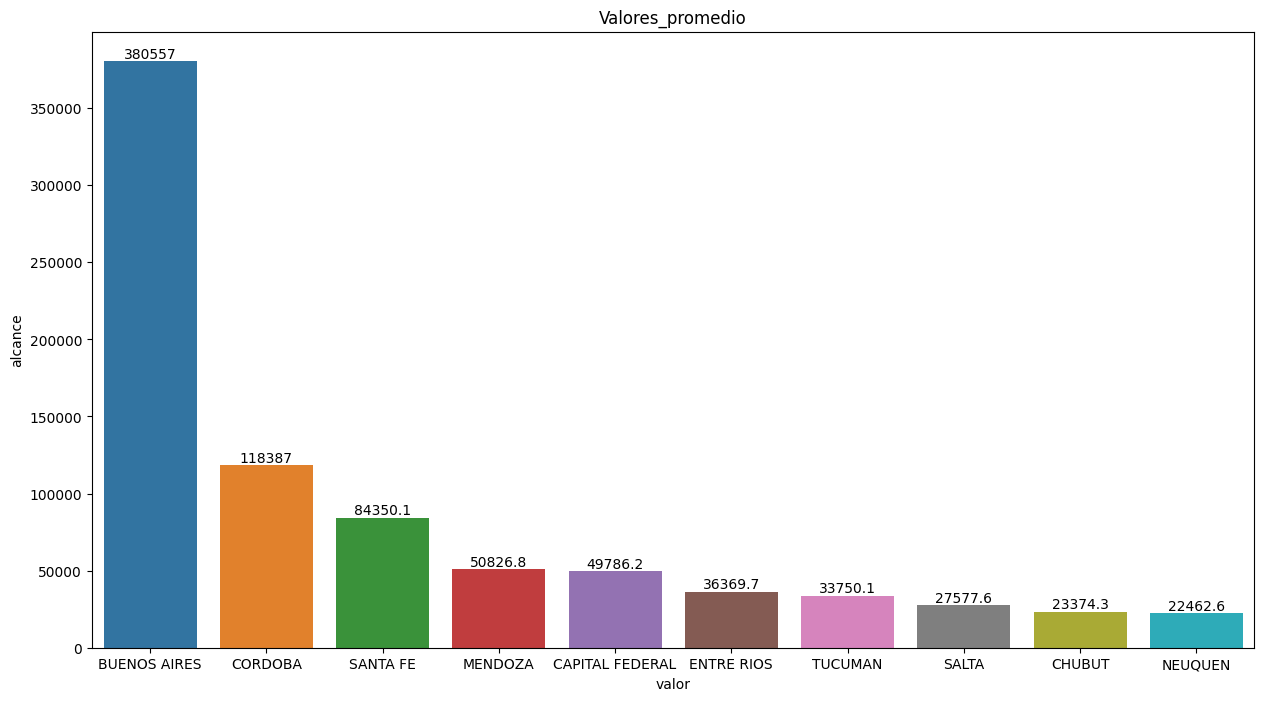

In [104]:
%matplotlib inline
plt.figure(figsize=(15,8))

ax = sns.barplot(data=df.groupby('alcance')['valor'].mean().nlargest(10).reset_index(),
                 x='alcance',
                 y = 'valor')

ax.set(xlabel='valor', ylabel='alcance', title = 'Valores_promedio')
plt.bar_label(ax.containers[0], size=10)
plt.tight_layout
plt.show()

In [107]:
df['valor'].value_counts()

2.371053e+01    7
7.501957e+00    6
2.281000e+02    6
4.883883e+00    6
1.000000e+02    5
               ..
4.342500e+04    1
5.034900e+04    1
4.425200e+04    1
4.178000e+04    1
5.376047e+06    1
Name: valor, Length: 11782, dtype: int64

In [108]:
df = df[df['alcance']!='Title: Argentina']
df['alcance'].value_counts()

Argentina              6727
MENDOZA                 228
TUCUMAN                 228
SANTIAGO DEL ESTERO     228
SANTA FE                228
SANTA CRUZ              228
SAN LUIS                228
SAN JUAN                228
SALTA                   228
RIO NEGRO               228
NEUQUEN                 228
MISIONES                228
LA RIOJA                228
CAPITAL FEDERAL         228
LA PAMPA                228
JUJUY                   228
FORMOSA                 228
ENTRE RIOS              228
CHUBUT                  228
CHACO                   228
CORRIENTES              228
CORDOBA                 228
CATAMARCA               228
BUENOS AIRES            228
TIERRA DEL FUEGO        228
Name: alcance, dtype: int64

In [111]:
## ANALIZAMOS EN UN solo grafico valores maximos, medios y minimos para todas las provincias

<Axes: xlabel='alcance', ylabel='valor'>

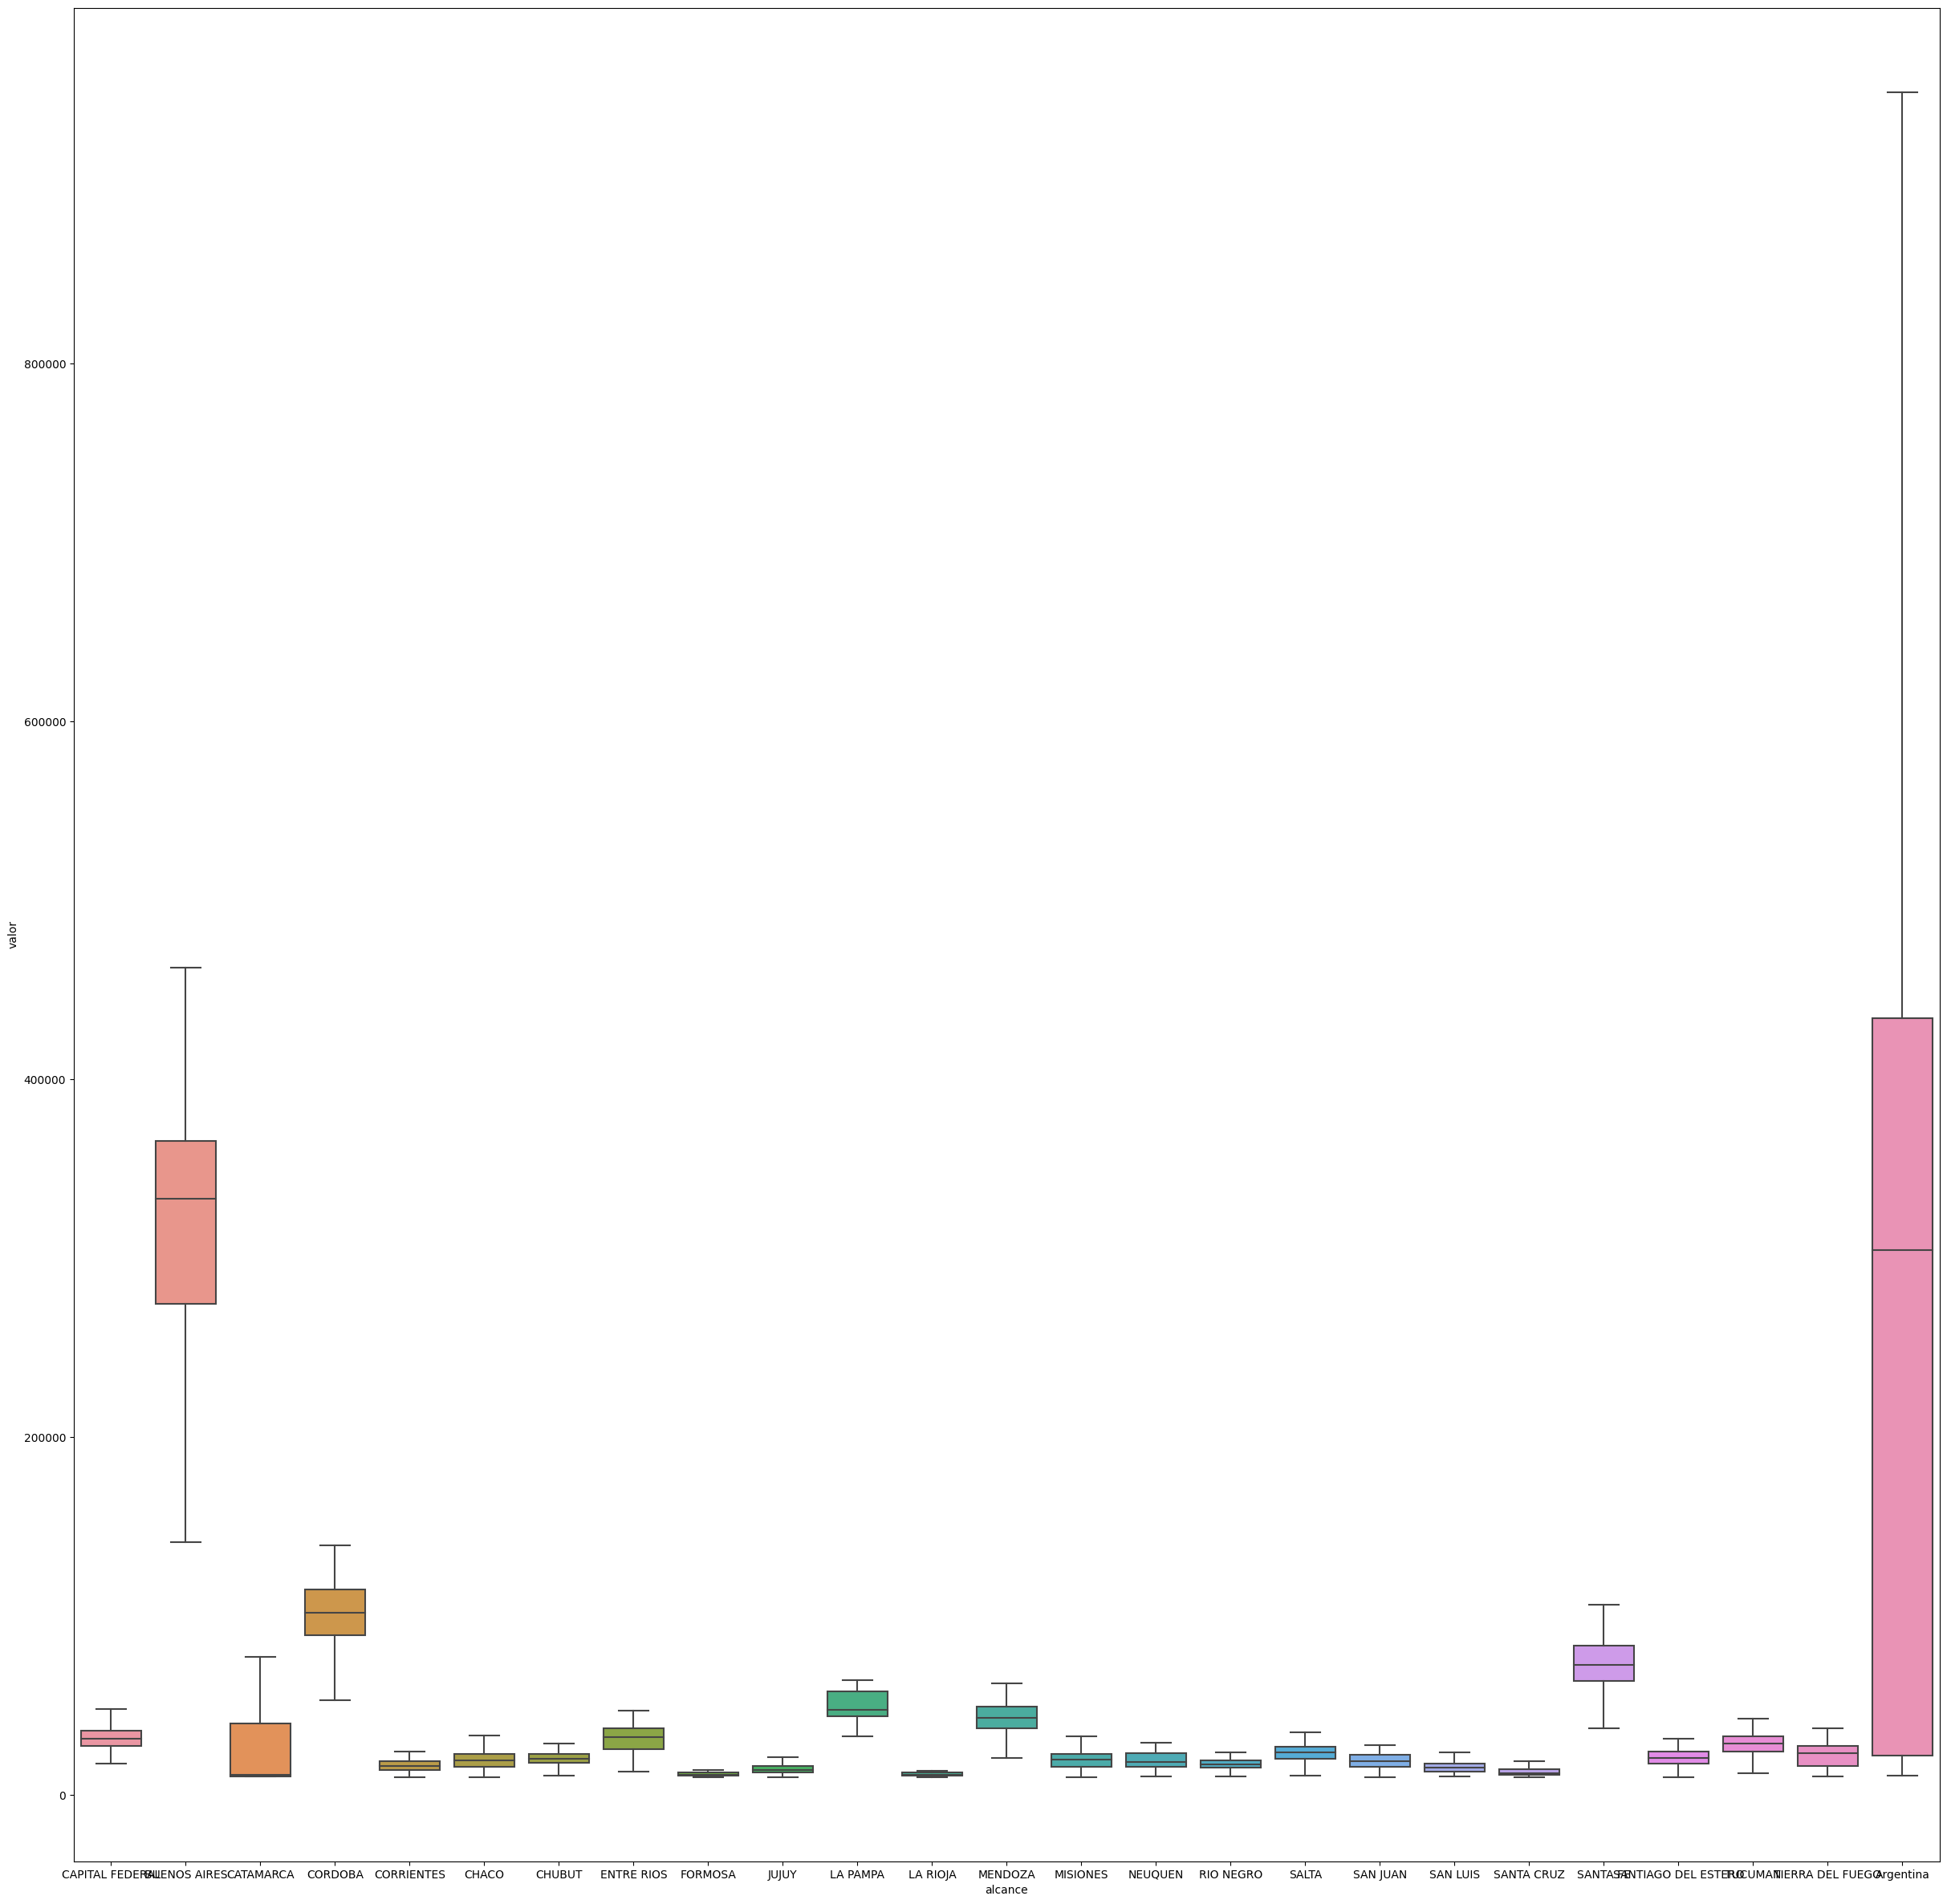

In [112]:
plt.figure(figsize=(30,30))
uno_df = df[df['valor']>10000]

sns.boxplot(data=uno_df,
           x='alcance' ,
           y='valor',
           showfliers=False)



EMPEZAMOS ANALIZAR LOS GRAFICOS POR AÑO Y POR PROVINCIA Y POR PRODUCTO Y UNIDAD DE MEDIDA

In [114]:
tn_cemento_mensual_mendoza=tn_cemento.loc[(tn_cemento['frecuencia']=='Mensual')&(tn_cemento['alcance']=='MENDOZA')&(tn_cemento['anio']==2021)] #Filtro por frecuencia Mensual,en Mendoza, año 2021
tn_cemento_mensual_mendoza  #AFCP= Asociacion de Fabricantes de Cemento Portland HICIMOS UN FILTRO PARA LA PROVINCIA DE MENDOZA POR AÑO

,ID,sector,variable,producto,indicador,unidad_de_medida,fuente,frecuencia,cobertura,alcance_tipo,alcance_id,alcance,fecha,valor,anio,mes,day
4260,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-01-01,45302.0,2021,1,1
4261,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-02-01,39132.0,2021,2,1
4262,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-03-01,51026.0,2021,3,1
4263,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-04-01,47647.0,2021,4,1
4264,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-05-01,44811.0,2021,5,1
4265,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-06-01,47649.0,2021,6,1
4266,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-07-01,57056.0,2021,7,1
4267,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-08-01,56596.0,2021,8,1
4268,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-09-01,62451.0,2021,9,1
4269,24,Construcción,397,Cemento portland,Consumo,tn,AFCP,Mensual,Nacional,PROVINCIA,50,MENDOZA,2021-10-01,61378.0,2021,10,1


<Axes: >

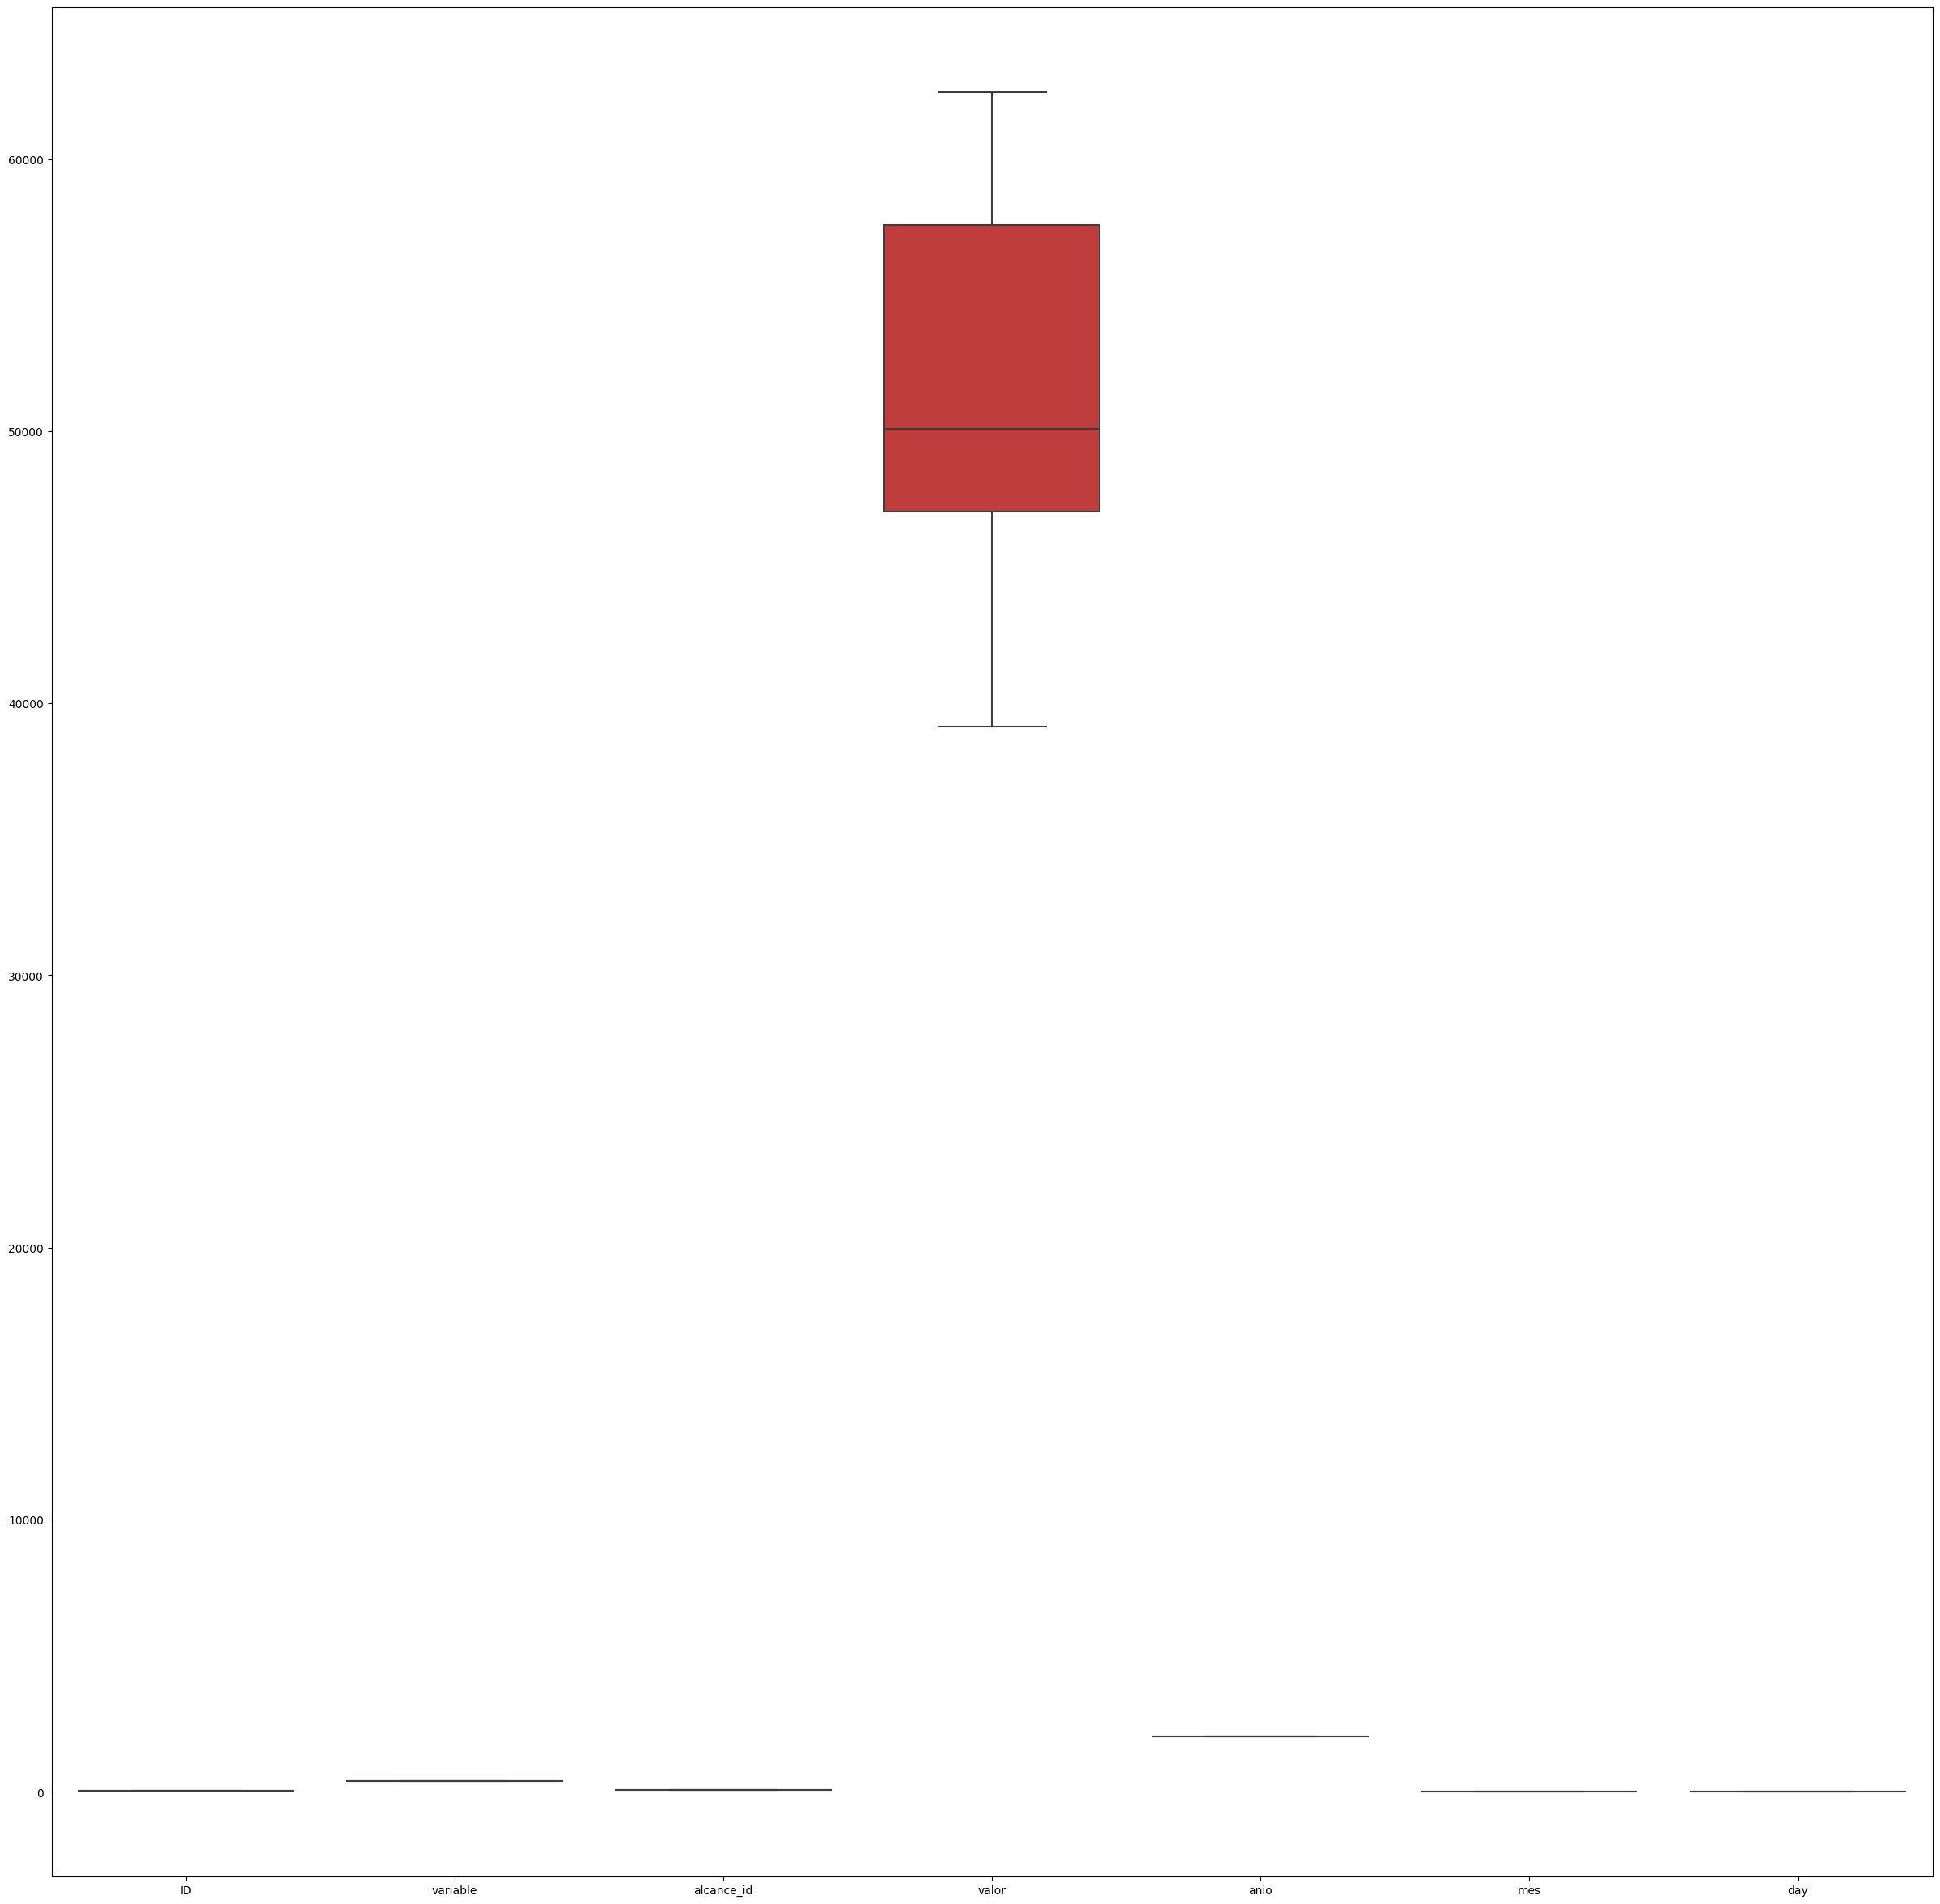

In [121]:
plt.figure(figsize=(30,30))
dos_df = [tn_cemento_mensual_mendoza ]

sns.boxplot( tn_cemento_mensual_mendoza)


In [ ]:
## ver https://github.com/ydataai/ydata-profiling

EXISTE UNA FORMA MAS RAPIDA DE HACER EL ANALISIS EDA EN UN DATAFRAME, PARA ELLO SE ENCONTRO INFORMACION DE LAS SIGUIENTES PAGINAS WEB.https://towardsdatascience.com/how-to-do-an-eda-for-time-series-cbb92b3b1913
https://towardsdatascience.com/awesome-data-science-tools-to-master-in-2023-data-profiling-edition-29d29310f779

Se analizaron las formulas de las mismas y se realizo en nuestro dataframe

In [122]:
pip install ydata-profiling

In [123]:
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport


In [124]:
profile = ProfileReport(df, title="Profiling Report")

In [125]:
from sklearn.preprocessing import OneHotEncoder

In [126]:
print(ProfileReport)

<class 'ydata_profiling.profile_report.ProfileReport'>


In [ ]:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]